In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from pathlib import Path

PROC_DIR = Path("../data/processed")

expr = pd.read_csv(PROC_DIR / "expression_final.csv", index_col=0)
drug = pd.read_csv(PROC_DIR / "drug_final.csv")

print("expression:", expr.shape)
print("drug:", drug.shape)
print("unique drugs:", drug['inhibitor'].nunique())
print("unique patients:", drug['cbio_patient_id'].nunique())

expression: (318, 22834)
drug: (34764, 5)
unique drugs: 122
unique patients: 318


In [3]:
# check drug coverage

drug_coverage = drug.groupby('inhibitor')['cbio_patient_id'].nunique().sort_values()

print(f"min patients per drug: {drug_coverage.min()}")
print(f"max patients per drug: {drug_coverage.max()}")
print(f"median patients per drug: {drug_coverage.median()}")
print(f"\ndrugs with <50 patients: {(drug_coverage < 50).sum()}")
print(f"drugs with <100 patients: {(drug_coverage < 100).sum()}")
print(f"drugs with >=200 patients: {(drug_coverage >= 200).sum()}")
print(f"\nbottom 10 drugs by coverage:")
print(drug_coverage.head(10))

min patients per drug: 65
max patients per drug: 310
median patients per drug: 282.5

drugs with <50 patients: 0
drugs with <100 patients: 8
drugs with >=200 patients: 100

bottom 10 drugs by coverage:
inhibitor
Entrectinib                65
Lestaurtinib (CEP-701)     79
Tandutinib (MLN518)        80
TG101348                   81
Go6976                     82
PLX-4720                   83
Selinexor                  84
Staurosporine              84
BI-2536                   103
Lenalidomide              107
Name: cbio_patient_id, dtype: int64


AUC summary statistics:
count    34764.000000
mean       199.751348
std         60.175464
min          3.559088
25%        160.085143
50%        209.162990
75%        247.560546
max        286.327000
Name: auc, dtype: float64

missing AUC values: 0
AUC <= 0: 0
AUC > 500: 0


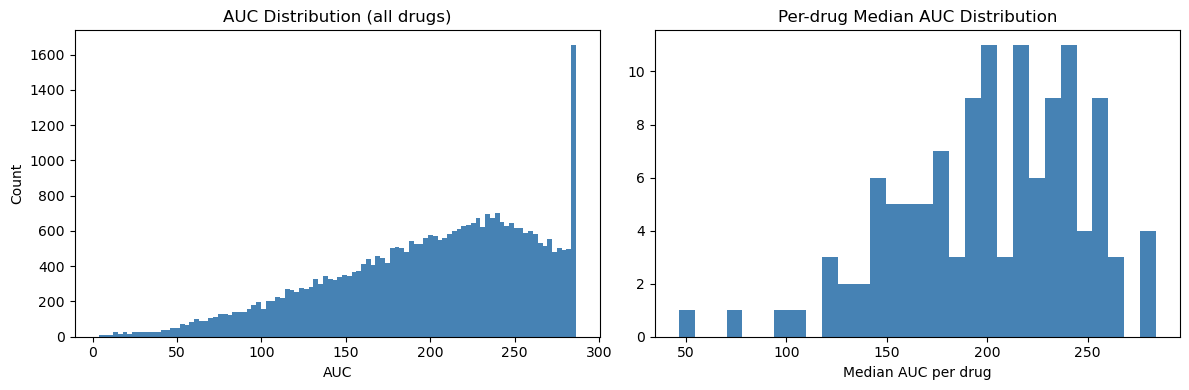

Saved.


In [4]:
# check auc distribution

print("AUC summary statistics:")
print(drug['auc'].describe())
print(f"\nmissing AUC values: {drug['auc'].isnull().sum()}")
print(f"AUC <= 0: {(drug['auc'] <= 0).sum()}")
print(f"AUC > 500: {(drug['auc'] > 500).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(drug['auc'], bins=100, edgecolor='none', color='steelblue')
axes[0].set_xlabel('AUC')
axes[0].set_ylabel('Count')
axes[0].set_title('AUC Distribution (all drugs)')

drug_medians = drug.groupby('inhibitor')['auc'].median().sort_values()
axes[1].hist(drug_medians, bins=30, edgecolor='none', color='steelblue')
axes[1].set_xlabel('Median AUC per drug')
axes[1].set_title('Per-drug Median AUC Distribution')

plt.tight_layout()
plt.savefig('../results/figures/auc_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

In [5]:
# variance filtering on gene expression

gene_variance = expr.var(axis=0)
print("gene variance summary:")
print(gene_variance.describe())

thresholds = [0.1, 0.5, 1.0, 1.5]
for t in thresholds:
    print(f"genes with variance > {t}: {(gene_variance > t).sum()}")

gene variance summary:
count    22834.000000
mean         2.165004
std         14.426227
min          0.239966
25%          0.950565
50%          1.080452
75%          2.200564
max       1672.337518
dtype: float64
genes with variance > 0.1: 22834
genes with variance > 0.5: 22832
genes with variance > 1.0: 14121
genes with variance > 1.5: 8560


In [7]:
#  apply variance filter & save

high_var_genes = gene_variance[gene_variance > 1.0].index
expr_filtered = expr[high_var_genes]
print("expression after variance filtering:", expr_filtered.shape)

expr_filtered.to_csv(PROC_DIR / "expression_filtered.csv")
print("saved expression_filtered.csv")

expression after variance filtering: (318, 14121)
saved expression_filtered.csv


In [9]:
# check clinical metadata coverage for the 318 patients

clin_sample = pd.read_csv(
    Path("../data/raw/aml_ohsu_2022/data_clinical_sample.txt"),
    sep="\t", comment="#"
)

clin_sample['cbio_patient_id'] = clin_sample['PATIENT_ID']
clin_cohort = clin_sample[clin_sample['cbio_patient_id'].isin(expr_filtered.index)]

print("clinical records for the 318 patients:", len(clin_cohort))
print("unique patients covered:", clin_cohort['cbio_patient_id'].nunique())

cols_of_interest = ['ELN2017', 'FLT3_ITD', 'NPM1', 'TP53', 'RUNX1', 'ASXL1']
print("\ncoverage of key biological variables:")
for col in cols_of_interest:
    non_null = clin_cohort[col].notna().sum()
    print(f"  {col}: {non_null} / {clin_cohort['cbio_patient_id'].nunique()} patients")

clinical records for the 318 patients: 401
unique patients covered: 318

coverage of key biological variables:
  ELN2017: 401 / 318 patients
  FLT3_ITD: 394 / 318 patients
  NPM1: 392 / 318 patients
  TP53: 30 / 318 patients
  RUNX1: 45 / 318 patients
  ASXL1: 37 / 318 patients


In [10]:
# deduplicate clinical to one row per patient & save

clin_dedup = clin_cohort.sort_values('USED_IN_MANUSCRIPT', ascending=False)
clin_dedup = clin_dedup.drop_duplicates(subset='cbio_patient_id', keep='first')
print("after deduplication:", clin_dedup.shape)

cols_keep =  ['cbio_patient_id', 'ELN2017', 'FLT3_ITD', 'NPM1', 'ASXL1', 'TP53', 'RUNX1']
clin_final = clin_dedup[cols_keep].set_index('cbio_patient_id')

print("\nfinal clinical coverage:")
for col in clin_final.columns:
    print(f" {col}: {clin_final[col].notna().sum()} / {len(clin_final)}")

print("\nELN2017 distribution:")
print(clin_final['ELN2017'].value_counts(dropna=False))
clin_final.to_csv(PROC_DIR / "clinical_final.csv")
print("\nsaved clinical_final.csv")

after deduplication: (318, 43)

final clinical coverage:
 ELN2017: 318 / 318
 FLT3_ITD: 312 / 318
 NPM1: 311 / 318
 ASXL1: 29 / 318
 TP53: 25 / 318
 RUNX1: 35 / 318

ELN2017 distribution:
ELN2017
NonInitial                 87
Favorable                  84
Adverse                    83
Intermediate               48
NonAML                      6
FavorableOrIntermediate     4
IntermediateOrAdverse       3
MissingKaryo                2
MissingMutations            1
Name: count, dtype: int64

saved clinical_final.csv


In [11]:
# clean ELN2017 categories & save final version

eln_map = {
    'Favorable': 'Favorable',
    'Intermediate': 'Intermediate',
    'Adverse': 'Adverse',
    'NonInitial': 'NonInitial'
}
clin_final['ELN2017_clean'] = clin_final['ELN2017'].map(eln_map)

print("ELN2017_clean distribution:")
print(clin_final['ELN2017_clean'].value_counts(dropna=False))
print(f"\nPatients with clean ELN2017 label: {clin_final['ELN2017_clean'].notna().sum()}")
print(f"Excluded from ELN subgroup analysis: {clin_final['ELN2017_clean'].isna().sum()}")

clin_final.to_csv(PROC_DIR / "clinical_final.csv")
print("\nSaved.")

ELN2017_clean distribution:
ELN2017_clean
NonInitial      87
Favorable       84
Adverse         83
Intermediate    48
NaN             16
Name: count, dtype: int64

Patients with clean ELN2017 label: 302
Excluded from ELN subgroup analysis: 16

Saved.


In [15]:
# preprocessing summary

print("*" * 30)
print("preprocessing summary")
print("*" * 30)
print(f"modellable cohort:        {expr_filtered.shape[0]} patients")
print(f"gene features:            {expr_filtered.shape[1]} (after variance filtering)")
print(f"drugs:                    {drug['inhibitor'].nunique()}")
print(f"drug-patient pairs:       {len(drug)}")
print(f"min patients per drug:    {drug.groupby('inhibitor')['cbio_patient_id'].nunique().min()}")
print(f"max patients per drug:    {drug.groupby('inhibitor')['cbio_patient_id'].nunique().max()}")
print()
print("cinical variables for Phase 3:")
print(f"  ELN2017 (clean):        {clin_final['ELN2017_clean'].notna().sum()} / 318 patients")
print(f"  FLT3_ITD:               {clin_final['FLT3_ITD'].notna().sum()} / 318 patients")
print(f"  NPM1:                   {clin_final['NPM1'].notna().sum()} / 318 patients")
print(f"  TP53/RUNX1/ASXL1:       too sparse, excluded from subgroup analysis")
print()
print("files saved to data/processed/:")
print("  expression_filtered.csv  (318 x 14121)")
print("  drug_final.csv           (34764 rows)")
print("  clinical_final.csv       (318 x clinical vars)")

******************************
preprocessing summary
******************************
modellable cohort:        318 patients
gene features:            14121 (after variance filtering)
drugs:                    122
drug-patient pairs:       34764
min patients per drug:    65
max patients per drug:    310

cinical variables for Phase 3:
  ELN2017 (clean):        302 / 318 patients
  FLT3_ITD:               312 / 318 patients
  NPM1:                   311 / 318 patients
  TP53/RUNX1/ASXL1:       too sparse, excluded from subgroup analysis

files saved to data/processed/:
  expression_filtered.csv  (318 x 14121)
  drug_final.csv           (34764 rows)
  clinical_final.csv       (318 x clinical vars)
